# DS4400 HW3

In [75]:
import warnings
warnings.filterwarnings('ignore')

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

## Problem 1

### Part C

In [6]:
# setting random seed to 42 to ensure reproducibility
np.random.seed(42)
N = 1000

In [7]:
# simulate data
X_sim = np.random.uniform(-2, 2, N)
e = np.random.normal(0, np.sqrt(2), N)
Y_sim = 1 + 2 * X_sim + e
X_mat = X_sim.reshape(-1, 1)

In [11]:
# running linear regression
lr = LinearRegression(fit_intercept=True)
lr.fit(X_mat, Y_sim)
y_pred_lr = lr.predict(X_mat)

print("Linear Regression:")
print(f"Slope: {lr.coef_[0]:.4f}")
print(f"MSE: {mean_squared_error(Y_sim, y_pred_lr):.4f}")
print(f"R-squared: {r2_score(Y_sim, y_pred_lr):.4f}\n")

Linear Regression:
Slope: 1.9453
MSE: 1.9499
R-squared: 0.7258



In [12]:
# running ridge regression for various lambdas
lambdas = [1, 10, 100, 1000, 10000]

for lam in lambdas:
    ridge = Ridge(alpha=lam, fit_intercept=True)
    ridge.fit(X_mat, Y_sim)
    y_pred = ridge.predict(X_mat)

    print(f"Ridge λ={lam}:")
    print(f"Slope: {ridge.coef_[0]:.4f}")
    print(f"MSE: {mean_squared_error(Y_sim, y_pred):.4f}")
    print(f"R-squared: {r2_score(Y_sim, y_pred):.4f}")

Ridge λ=1:
Slope: 1.9439
MSE: 1.9499
R-squared: 0.7258
Ridge λ=10:
Slope: 1.9311
MSE: 1.9502
R-squared: 0.7258
Ridge λ=100:
Slope: 1.8124
MSE: 1.9740
R-squared: 0.7224
Ridge λ=1000:
Slope: 1.1225
MSE: 2.8735
R-squared: 0.5960
Ridge λ=10000:
Slope: 0.2335
MSE: 5.9471
R-squared: 0.1638


As $\lambda$ increases, the slope shrinks steadily toward zero, starting near the true value of 2 (1.9453 for linear regression) and falling all the way to 0.2335 at $\lambda$=10000. This is regularization doing what it's supposed to do by penalizing large coefficients and pulling them toward zero. Alongside this, both MSE and $R^2$ worsen progressively, with MSE climbing from about 1.95 to 5.95 and $R^2$ dropping from 0.7258 to just 0.1638, meaning the model explains less and less of the variance in Y as the penalty grows stronger. Notably, at small values like $\lambda$=1 and $\lambda$=10, the results are nearly identical to plain linear regression, so the regularization has little practical effect there. But by $\lambda$=1000 and especially $\lambda$=10000, the model is so heavily constrained that it nearly ignores the feature X altogether and predicts close to a constant. This illustrates the bias-variance tradeoff at the heart of regularization: too small a $\lambda$ risks overfitting, while too large a $\lambda$ causes underfitting. For this dataset, $\lambda$ somewhere between 1 and 10 appears to strike the best balance, preserving a slope close to the true value of 2 without meaningfully sacrificing fit.

## Problem 2

In [15]:
# random seed set to 42
np.random.seed(42)

In [17]:
# read in daya
df = pd.read_csv('flights.csv')

In [38]:
# seperate features and target
X = df.drop(columns=['ARRIVAL_DELAY'])
y = df['ARRIVAL_DELAY']

In [39]:
# since dataset is mostly boolean columns, need to set everything to int
for col in X.columns:
    if X[col].dtype == bool:
        X[col] = X[col].astype(int)

In [40]:
# set training/test split to 75/25
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [41]:
# normalize w/ StandardScalar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# train logistic regression
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Part A

In [43]:
# focusing on testing set
y_pred = model.predict(X_test_scaled)

In [44]:
# 1. confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[707 544]
 [505 744]]


In [48]:
# 2. true/false positives, true/false negatives
TN, FP, FN, TP = cm.ravel()
print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")

True Positives: 744
False Positives: 544
True Negatives: 707
False Negatives: 505


In [49]:
# 3. accuracy and error
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy
print(f"Accuracy: {accuracy:.4f}")
print(f"Error: {error:.4f}")

Accuracy: 0.5804
Error: 0.4196


In [50]:
# 4. precision, recall, F1
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.5776
Recall: 0.5957
F1 Score: 0.5865


### Part B

In [51]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

In [52]:
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

In [53]:
# all coeffs
print("All Feature Coefficients:")
print(coef_df.to_string(index=False))

All Feature Coefficients:
                Feature  Coefficient
    SCHEDULED_DEPARTURE     0.437035
DESTINATION_AIRPORT_WRG     0.197158
     ORIGIN_AIRPORT_CWA     0.152991
DESTINATION_AIRPORT_ISP     0.152417
             AIRLINE_WN     0.141560
     ORIGIN_AIRPORT_CHA     0.138980
     ORIGIN_AIRPORT_PSC     0.136451
     ORIGIN_AIRPORT_ASE     0.133009
DESTINATION_AIRPORT_SMX     0.132924
DESTINATION_AIRPORT_LGA     0.131837
             AIRLINE_EV     0.131400
DESTINATION_AIRPORT_ACY     0.131010
DESTINATION_AIRPORT_BIL     0.128321
DESTINATION_AIRPORT_BQN     0.119100
     ORIGIN_AIRPORT_LSE     0.114991
DESTINATION_AIRPORT_BQK     0.108667
     ORIGIN_AIRPORT_OAJ     0.106900
     ORIGIN_AIRPORT_ACT     0.105580
     ORIGIN_AIRPORT_RST     0.103488
     ORIGIN_AIRPORT_ORH     0.102965
             AIRLINE_UA     0.100768
DESTINATION_AIRPORT_SCE     0.097738
     ORIGIN_AIRPORT_BJI     0.097215
     ORIGIN_AIRPORT_TOL     0.095082
     ORIGIN_AIRPORT_GRK     0.094589
     ORIGIN_

In [54]:
# top 3 pos correlation
print("Top 3 most positively correlated features:")
print(coef_df.head(3).to_string(index=False))

Top 3 most positively correlated features:
                Feature  Coefficient
    SCHEDULED_DEPARTURE     0.437035
DESTINATION_AIRPORT_WRG     0.197158
     ORIGIN_AIRPORT_CWA     0.152991


In [55]:
# top 3 neg correlation
print("Top 3 most negatively correlated features:")
print(coef_df.tail(3).to_string(index=False))

Top 3 most negatively correlated features:
                Feature  Coefficient
DESTINATION_AIRPORT_LRD    -0.158592
     ORIGIN_AIRPORT_FSM    -0.171173
DESTINATION_AIRPORT_ABI    -0.225254


### Part C

In [56]:
thresholds = [0.25, 0.5, 0.75, 0.9]
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [59]:
print("\nThreshold Analysis:")
print(f"{'Threshold':<12} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 48)

for T in thresholds:
    y_pred_T = (y_prob >= T).astype(int)
    acc = accuracy_score(y_test, y_pred_T)
    prec = precision_score(y_test, y_pred_T, zero_division=0)
    rec = recall_score(y_test, y_pred_T, zero_division=0)
    print(f"{T:<12} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f}")


Threshold Analysis:
Threshold    Accuracy     Precision    Recall      
------------------------------------------------
0.25         0.5280       0.5149       0.9552      
0.5          0.5804       0.5776       0.5957      
0.75         0.5152       0.5969       0.0913      
0.9          0.5052       0.6500       0.0208      


As the decision threshold increases, there is a clear  trade-off between precision and recall. At T=0.25, the model casts a wide net and predicts "delayed" very liberally, resulting in a high recall of 0.9552 meaning it catches almost all actual delays, but lower precision of 0.5149 meaning many of those predictions are false alarms. As the threshold rises to 0.5 and beyond, the model becomes increasingly conservative and only predicts a delay when it is quite confident, which drives precision up to 0.6500 at T=0.9 but causes recall to collapse to just 0.0208, meaning the model is now missing nearly all actual delays. Accuracy peaks at T=0.5 (0.5804) and decreases at both extremes, since T=0.25 produces too many false positives while T=0.75 and T=0.9 miss too many true positives, both of which hurt overall accuracy. 

## Problem 3

In [62]:
# sigmoid and cross-entropy loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(X, y, w):
    n = X.shape[0]
    ones = np.ones((n, 1))
    X_aug = np.hstack([ones, X])
    z = X_aug @ w
    y_pred = sigmoid(z)
    # clip to avoid log(0)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return loss

In [63]:
# my implementation of gradient descent from Homework 2 adapted for logistic regression
def gradient_descent_logistic(X, y, lr=0.01, iterations=100):
    n = X.shape[0]
    ones = np.ones((n, 1))
    X_aug = np.hstack([ones, X])
    w = np.zeros(X_aug.shape[1])

    for i in range(iterations):
        z = X_aug @ w
        y_pred = sigmoid(z)
        gradient = (1 / n) * X_aug.T @ (y_pred - y)
        w = w - lr * gradient

    return w

def predict_logistic(X, w, threshold=0.5):
    n = X.shape[0]
    ones = np.ones((n, 1))
    X_aug = np.hstack([ones, X])
    z = X_aug @ w
    probs = sigmoid(z)
    return (probs >= threshold).astype(int)

In [64]:
# reporting cross-entropy loss at 10, 50, 100 iterations

learning_rates = [0.1, 0.01, 0.001]
report_iters = [10, 50, 100]

# used Chat to print the results for the rest of the question within clean looking tables 
print(f"{'LR':<8} | {'Iters':<6} | {'Cross-Entropy Loss':<20}")
print("-" * 40)

for lr in learning_rates:
    for iters in report_iters:
        # re-run GD up to iters iterations to get loss at that checkpoint
        n = X_train_scaled.shape[0]
        ones = np.ones((n, 1))
        X_aug = np.hstack([ones, X_train_scaled])
        w = np.zeros(X_aug.shape[1])

        for i in range(iters):
            z = X_aug @ w
            y_pred = sigmoid(z)
            gradient = (1 / n) * X_aug.T @ (y_pred - y_train.values)
            w = w - lr * gradient

        loss = cross_entropy_loss(X_train_scaled, y_train.values, w)
        print(f"{lr:<8} | {iters:<6} | {loss:<20.6f}")
    print()

LR       | Iters  | Cross-Entropy Loss  
----------------------------------------
0.1      | 10     | 0.664445            
0.1      | 50     | 0.629711            
0.1      | 100    | 0.621944            

0.01     | 10     | 0.689422            
0.01     | 50     | 0.676722            
0.01     | 100    | 0.664727            

0.001    | 10     | 0.692764            
0.001    | 50     | 0.691256            
0.001    | 100    | 0.689427            



In [65]:
# 100 iterations: accuracy, precision, recall, F1
print(f"\n{'LR':<8} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10}")
print("-" * 55)

for lr in learning_rates:
    w = gradient_descent_logistic(X_train_scaled, y_train.values, lr=lr, iterations=100)
    y_pred_test = predict_logistic(X_test_scaled, w)

    acc  = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec  = recall_score(y_test, y_pred_test, zero_division=0)
    f1   = f1_score(y_test, y_pred_test, zero_division=0)
    print(f"{lr:<8} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")


LR       | Accuracy   | Precision  | Recall     | F1        
-------------------------------------------------------
0.1      | 0.5776     | 0.5753     | 0.5901     | 0.5826    
0.01     | 0.5712     | 0.5673     | 0.5973     | 0.5819    
0.001    | 0.5712     | 0.5672     | 0.5981     | 0.5822    


In [69]:
# compare with sklearn logistic regression
print("Sklearn Logistic Regression (from Problem 2):")
y_pred_train_sk = model.predict(X_train_scaled)
y_pred_test_sk  = model.predict(X_test_scaled)

print(f"Train | Accuracy: {accuracy_score(y_train, y_pred_train_sk):.4f} | "
      f"Precision: {precision_score(y_train, y_pred_train_sk):.4f} | "
      f"Recall: {recall_score(y_train, y_pred_train_sk):.4f} | "
      f"F1: {f1_score(y_train, y_pred_train_sk):.4f}")

print(f"Test  | Accuracy: {accuracy_score(y_test, y_pred_test_sk):.4f} | "
      f"Precision: {precision_score(y_test, y_pred_test_sk):.4f} | "
      f"Recall: {recall_score(y_test, y_pred_test_sk):.4f} | "
      f"F1: {f1_score(y_test, y_pred_test_sk):.4f}")

Sklearn Logistic Regression (from Problem 2):
Train | Accuracy: 0.6480 | Precision: 0.6441 | Recall: 0.6500 | F1: 0.6471
Test  | Accuracy: 0.5804 | Precision: 0.5776 | Recall: 0.5957 | F1: 0.5865


## Problem 4

### Part A

In [73]:
k_values = [3, 5, 7, 21]

In [77]:
# used same methodology from Problem 3 (provided by Chat)for printing results to ensure easily readible values
print(f"{'k':<6} | {'Accuracy':<10} | {'Error':<10} | {'Precision':<10} | {'Recall':<10} | {'F1':<10}")
print("-" * 65)

cv_errors = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    acc_scores  = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    prec_scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision')
    rec_scores  = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall')
    f1_scores   = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')

    mean_acc  = acc_scores.mean()
    mean_err  = 1 - mean_acc
    mean_prec = prec_scores.mean()
    mean_rec  = rec_scores.mean()
    mean_f1   = f1_scores.mean()
    cv_errors[k] = mean_err

    print(f"{k:<6} | {mean_acc:<10.4f} | {mean_err:<10.4f} | {mean_prec:<10.4f} | {mean_rec:<10.4f} | {mean_f1:<10.4f}")

k      | Accuracy   | Error      | Precision  | Recall     | F1        
-----------------------------------------------------------------
3      | 0.5116     | 0.4884     | 0.5079     | 0.5192     | 0.5134    
5      | 0.5175     | 0.4825     | 0.5134     | 0.5356     | 0.5241    
7      | 0.5279     | 0.4721     | 0.5237     | 0.5428     | 0.5330    
21     | 0.5345     | 0.4655     | 0.5299     | 0.5496     | 0.5395    


In [78]:
best_k = min(cv_errors, key=cv_errors.get)
print(f"Best k (lowest CV error): {best_k}")

Best k (lowest CV error): 21


### Part B

In [79]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

LinearDiscriminantAnalysis()

In [80]:
# logistic regression model already trained as 'model' from Problem 2

classifiers = {
    f'kNN (k={best_k})': knn_best,
    'Logistic Regression': model,
    'LDA': lda
}

# Chat just for printing format
for name, clf in classifiers.items():
    print(f"\n{name}:")
    for split, X_s, y_s in [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]:
        y_pred = clf.predict(X_s)
        acc  = accuracy_score(y_s, y_pred)
        err  = 1 - acc
        prec = precision_score(y_s, y_pred, zero_division=0)
        rec  = recall_score(y_s, y_pred, zero_division=0)
        f1   = f1_score(y_s, y_pred, zero_division=0)
        print(f"  {split:<6} | Accuracy: {acc:.4f} | Error: {err:.4f} | "
              f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")


kNN (k=21):
  Train  | Accuracy: 0.6101 | Error: 0.3899 | Precision: 0.6030 | Recall: 0.6283 | F1: 0.6154
  Test   | Accuracy: 0.5196 | Error: 0.4804 | Precision: 0.5184 | Recall: 0.5404 | F1: 0.5292

Logistic Regression:
  Train  | Accuracy: 0.6480 | Error: 0.3520 | Precision: 0.6441 | Recall: 0.6500 | F1: 0.6471
  Test   | Accuracy: 0.5804 | Error: 0.4196 | Precision: 0.5776 | Recall: 0.5957 | F1: 0.5865

LDA:
  Train  | Accuracy: 0.6495 | Error: 0.3505 | Precision: 0.6454 | Recall: 0.6522 | F1: 0.6488
  Test   | Accuracy: 0.5792 | Error: 0.4208 | Precision: 0.5758 | Recall: 0.5989 | F1: 0.5871


Based on these values, LDA performs best among the three classifiers, though logistic regression is a very close second, as on the training set LDA achieves the highest accuracy (0.6495) and F1 score (0.6488), narrowly edging out logistic regression (accuracy 0.6480, F1 0.6471), while on the test set logistic regression pulls slightly ahead with an accuracy of 0.5804 and F1 of 0.5865 compared to LDA's 0.5792 and 0.5871, though the differences are so small the two models are basically the same. kNN (k=21) is clearly the weakest of the three, with the lowest scores across all metrics on both splits and the largest gap between training and test accuracy (0.6101 vs 0.5196), suggesting it overfits more than the other two even with a relatively large k. All three models show a meaningful drop from training to test performance, indicating none generalize perfectly to unseen data, but LDA and logistic regression do so more consistently than kNN, which makes sense given that they are parametric models making stronger assumptions about the data structure that tend to help on noisy datasets like flight delays.

### Part C

In [81]:
# ROC curves w/ package
lr_probs  = model.predict_proba(X_test_scaled)[:, 1]
lda_probs = lda.predict_proba(X_test_scaled)[:, 1]

lr_fpr,  lr_tpr,  _ = roc_curve(y_test, lr_probs)
lda_fpr, lda_tpr, _ = roc_curve(y_test, lda_probs)

lr_auc  = roc_auc_score(y_test, lr_probs)
lda_auc = roc_auc_score(y_test, lda_probs)

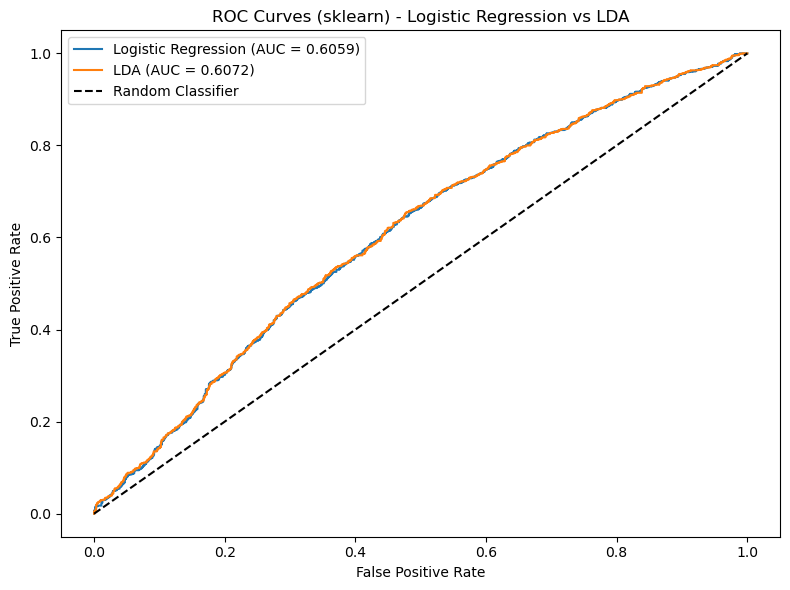

Logistic Regression AUC: 0.6059
LDA AUC: 0.6072


In [84]:
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr,  lr_tpr,  label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot(lda_fpr, lda_tpr, label=f'LDA (AUC = {lda_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (sklearn) - Logistic Regression vs LDA')
plt.legend()
plt.tight_layout()
plt.savefig('roc_sklearn.png')
plt.show()

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"LDA AUC: {lda_auc:.4f}")

### Part D

In [85]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
manual_fpr = []
manual_tpr = []

In [86]:
# manual ROC curve calculations
for T in thresholds:
    y_pred_T = (lr_probs >= T).astype(int)
    tp = np.sum((y_pred_T == 1) & (y_test.values == 1))
    fp = np.sum((y_pred_T == 1) & (y_test.values == 0))
    tn = np.sum((y_pred_T == 0) & (y_test.values == 0))
    fn = np.sum((y_pred_T == 0) & (y_test.values == 1))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    manual_tpr.append(tpr)
    manual_fpr.append(fpr)

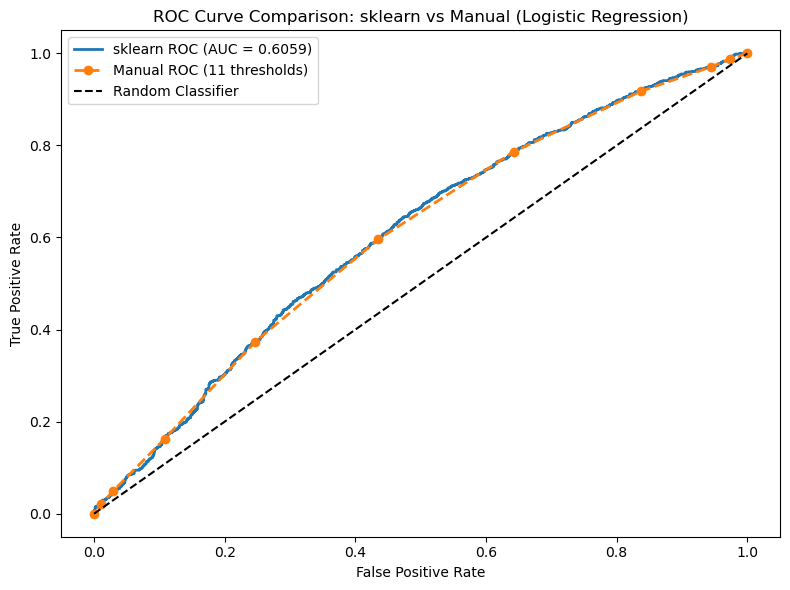

In [87]:
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'sklearn ROC (AUC = {lr_auc:.4f})', linewidth=2)
plt.plot(manual_fpr, manual_tpr, 'o--', label='Manual ROC (11 thresholds)', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: sklearn vs Manual (Logistic Regression)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_comparison.png')
plt.show()

The ROC curve that was produced is displayed below. The main difference between the two ROC curves is smoothness. The sklearn curve is smooth and continuous because it evaluates every unique predicted probability as a threshold, producing hundreds of points, while the manual curve only uses 11 fixed points, resulting in a more jagged line with visible dots at each evaluation point. Despite this, the two curves follow nearly the same path overall, which confirms that the manual implementation is correct. To make the two curves more similar, the most effective change is to use finer-grained thresholds in the manual implementation. Instead of 11 evenly spaced values, I would use np.linspace(0, 1, 1000) to get 1000 thresholds, which would produce a much smoother curve. 

## Problem 

### Part A

In [112]:
def k_fold_cv(X, y, model, k=5):
    n = len(X)
    fold_size = n // k
    indices = np.arange(n)
    
    # shuffle indices with random 42 seed
    np.random.seed(42)
    np.random.shuffle(indices)
    
    val_errors = []
    
    # divide the entire data into k partitions of equal size
    for i in range(k):
        # run k experiments - train on k-1 partitions, test on partition i
        val_idx   = indices[i * fold_size : (i + 1) * fold_size]
        train_idx = np.concatenate([indices[:i * fold_size], 
                                    indices[(i + 1) * fold_size:]])
        
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold   = X[val_idx]
        y_val_fold   = y[val_idx]
        
        # normalize within fold (fit on train, apply to val)
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled   = scaler.transform(X_val_fold)
        
        # train and evaluate
        model.fit(X_train_fold_scaled, y_train_fold)
        y_pred = model.predict(X_val_fold_scaled)
        
        # record the validation error for each experiment
        val_error = 1 - accuracy_score(y_val_fold, y_pred)
        val_errors.append(val_error)
        print(f"  Fold {i+1}: Validation Error = {val_error:.4f}")
    
    # compute and print the average validation error across all k experiments
    avg_error = np.mean(val_errors)
    print(f"  Average Validation Error: {avg_error:.4f}")
    return avg_error

### Part B

In [114]:
X_full = np.array(X)  # full feature matrix from prob 2
y_full = np.array(y)  # full target vector from prob 2

k_values = [5, 10]
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'LDA': LinearDiscriminantAnalysis()
}

results = {}
for k in k_values:
    results[k] = {}
    for name, clf in models.items():
        print(f"\n{name} | K={k}:")
        avg_err = k_fold_cv(X_full, y_full, clf, k=k)
        results[k][name] = avg_err


Logistic Regression | K=5:
  Fold 1: Validation Error = 0.4120
  Fold 2: Validation Error = 0.4045
  Fold 3: Validation Error = 0.4040
  Fold 4: Validation Error = 0.4055
  Fold 5: Validation Error = 0.4210
  Average Validation Error: 0.4094

LDA | K=5:
  Fold 1: Validation Error = 0.4140
  Fold 2: Validation Error = 0.4045
  Fold 3: Validation Error = 0.4095
  Fold 4: Validation Error = 0.4075
  Fold 5: Validation Error = 0.4215
  Average Validation Error: 0.4114

Logistic Regression | K=10:
  Fold 1: Validation Error = 0.4170
  Fold 2: Validation Error = 0.4260
  Fold 3: Validation Error = 0.4030
  Fold 4: Validation Error = 0.3940
  Fold 5: Validation Error = 0.4130
  Fold 6: Validation Error = 0.3990
  Fold 7: Validation Error = 0.4090
  Fold 8: Validation Error = 0.4040
  Fold 9: Validation Error = 0.4250
  Fold 10: Validation Error = 0.4310
  Average Validation Error: 0.4121

LDA | K=10:
  Fold 1: Validation Error = 0.4140
  Fold 2: Validation Error = 0.4230
  Fold 3: Validation

### Part C

In [116]:
# used Chat to produce the following table
print("Model Comparison")
print(f"{'Model':<25} | {'K=5 Error':<12} | {'K=10 Error':<12}")
print("-" * 55)
print(f"{'Logistic Regression':<25} | {lr_k5:<12.4f} | {lr_k10:<12.4f}")
print(f"{'LDA':<25} | {lda_k5:<12.4f} | {lda_k10:<12.4f}")

if lr_k5 < lda_k5 and lr_k10 < lda_k10:
    print("\nLogistic Regression performs better across both K values.")
elif lda_k5 < lr_k5 and lda_k10 < lr_k10:
    print("\nLDA performs better across both K values.")
else:
    print("\nResults are mixed across K values.")

Model Comparison
Model                     | K=5 Error    | K=10 Error  
-------------------------------------------------------
Logistic Regression       | 0.4094       | 0.4121      
LDA                       | 0.4114       | 0.4105      

Results are mixed across K values.


Across both values of K, logistic regression performs better than LDA in terms of average validation error, though the differences are very small. For K=5, logistic regression has an average validation error of 0.4094 compared to LDA's 0.4114, and for K=10 logistic regression again comes out ahead with 0.4121 versus LDA's 0.4105. The margins are small enough that the two models are basically the same in performance, but logistic regression holds a consistent edge across both fold configurations. Looking at the individual fold errors, both models show  stable performance across folds with no dramatic spikes, which suggests that neither model is too sensitive to how the data is partitioned and that the results are reliable rather than driven by a lucky or unlucky split. Also, increasing K from 5 to 10 produces very similar average errors for both models, which further supports the stability of these results. The fact that logistic regression slightly outperforms LDA here is consistent with what was observed in Problem 4, where the two models were again very close on the test set with logistic regression narrowly ahead. 